# The Last Hike — a quantitative teardown \U0001F52C
### Cycle reconstruction · base-rate-adjusted events · a live rule with its false alarms counted

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Five cycles is
not a sample, and the study's job is to be useful anyway — by measuring the *structure* of the
problem rather than pretending to estimate its size.

> ⚠️ **Not investment advice.** Policy record hard-coded from the Fed's own publications; market
> data pinned as-of the date in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from lasthike import data, strategy as st

px = data.load_prices()
eq = px[data.EQUITY].dropna()
path = st.policy_path()
cycles = st.tightening_cycles(path)
print(f"as-of {data.AS_OF} | {len(path)} target changes since {path.index[0].date()}")
print(cycles.assign(first_hike=cycles["first_hike"].dt.date,
                    last_hike=cycles["last_hike"].dt.date).round(2).to_string(index=False))

as-of 2026-06-30 | 88 target changes since 1994-02-04
first_hike  last_hike  n_hikes  months  total_tightening
1994-02-04 1995-02-01        7 11.8900            2.7500
1999-06-30 2000-05-16        6 10.5500            1.5000
2004-06-30 2006-06-29       17 23.9500            4.0000
2015-12-16 2018-12-19        9 36.1000            2.0000
2022-03-17 2023-07-26       11 16.2900            5.0000


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Across the **5 tightening cycles** since the Fed began announcing its target in 1994, the S&P returned **+17.8%** in the twelve months after the cycle's true final hike, against an unconditional base rate of +10.1% — an excess of **+7.7%** (*t* = **+1.08**, 80% of cycles positive). With 5 events there is no *t*-statistic that can carry much weight, and the study says so rather than dressing eight observations as a finding. |
| **Tradability** | Mirage | None of that is available at the time. Nobody knew 2023-07-26 was the last hike until months of not-hiking had passed. A live rule — declare the cycle over after **6 quiet months** — fired 7 times, of which **43% were false alarms** (another hike followed within two years), and earned an excess of **-1.1%** at twelve months (*t* = -0.19) against the hindsight version's +7.7%. The delay alone gave up a median **+11.4%** between the true last hike and the day the rule could act — 64% of the whole twelve-month move. |

> \U0001F4A1 **In plain words.** The effect is real in hindsight and unavailable in real time.
> Those are compatible statements, and the gap between them is measurable.

## 1 · Hypotheses

- **H₁.** Twelve-month returns after a cycle's final hike exceed the unconditional base rate.
- **H₂.** The excess survives the recognition delay: shifting each event forward by the time it
  took to *know* leaves it intact.
- **H₃.** A live rule, including the pauses that turned out not to be endings, earns the same
  excess.
- **H₄ (power).** With five cycles, H₁ cannot be rejected or confirmed at any conventional
  level — so the study's contribution is the *structure*, not the estimate.

## 2 · The policy record, audited

88 moves, 1994-02-04 -> 2024-12-18
51 hikes, 37 cuts
every recorded move moves the target in the stated direction: OK


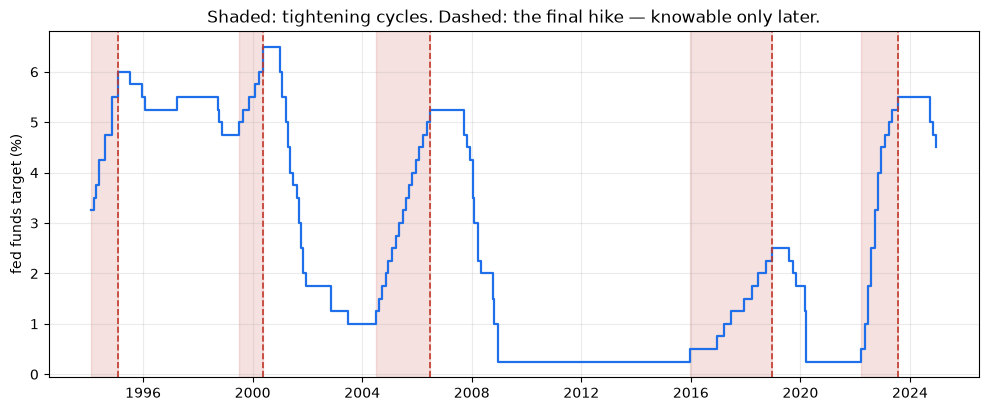

In [3]:
print(f"{len(path)} moves, {path.index[0].date()} -> {path.index[-1].date()}")
print(f"{int((path['direction'] > 0).sum())} hikes, {int((path['direction'] < 0).sum())} cuts")
d = path["target"].diff().dropna()
assert (np.sign(d.to_numpy()) == path["direction"].iloc[1:].to_numpy()).all()
print("every recorded move moves the target in the stated direction: OK")
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.step(path.index, path["target"], where="post", lw=1.6, color="#1f6feb")
for _, c in cycles.iterrows():
    ax.axvspan(c["first_hike"], c["last_hike"], color="#c0392b", alpha=0.15)
    ax.axvline(c["last_hike"], color="#c0392b", lw=1.2, ls="--")
ax.set_ylabel("fed funds target (%)")
ax.set_title("Shaded: tightening cycles. Dashed: the final hike — knowable only later.")
plt.show()

## 3 · The teardown

### 3.1 Hindsight, base-rate adjusted, four assets

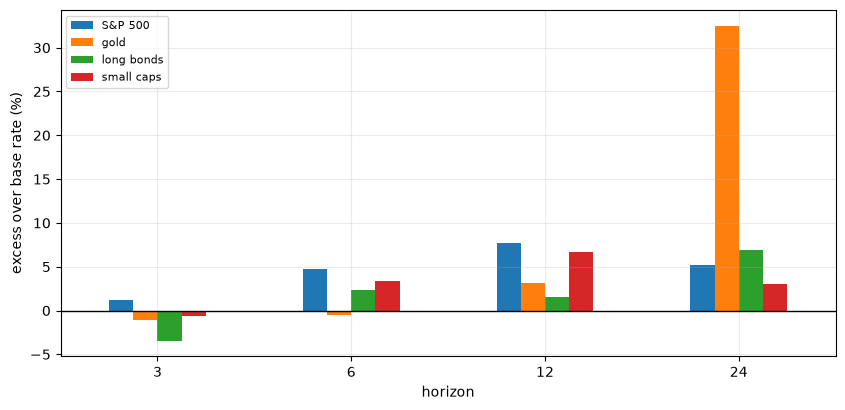

'     asset  horizon  excess       t  n\n   S&P 500        3  0.0126  0.3822  5\n   S&P 500        6  0.0474  1.0073  5\n   S&P 500       12  0.0772  1.0824  5\n   S&P 500       24  0.0516  0.4575  5\nlong bonds        3 -0.0345 -0.8792  3\nlong bonds        6  0.0234  0.4291  3\nlong bonds       12  0.0155  0.2090  3\nlong bonds       24  0.0693  0.6440  3\n      gold        3 -0.0111 -0.2330  3\n      gold        6 -0.0050 -0.0718  3\n      gold       12  0.0316  0.2904  3\n      gold       24  0.3250  1.7163  3\nsmall caps        3 -0.0064 -0.1400  5\nsmall caps        6  0.0341  0.5343  5\nsmall caps       12  0.0671  0.7392  5\nsmall caps       24  0.0304  0.2683  5'

In [4]:
rows = []
for label, tk in (("S&P 500", data.EQUITY), ("long bonds", data.LONG_BOND),
                  ("gold", data.GOLD), ("small caps", data.SMALL)):
    s = px[tk].dropna()
    if len(s) < 500:
        continue
    t = st.event_table(s, list(cycles["last_hike"]))
    for m, r in t.iterrows():
        rows.append({"asset": label, "horizon": int(m), "excess": r["excess"], "t": r["t"],
                     "n": int(r["n_events"])})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
d.pivot(index="horizon", columns="asset", values="excess").mul(100).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("excess over base rate (%)"); ax.legend(fontsize=8, title="")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()
d.round(4).to_string(index=False)

### 3.2 The live rule and its false alarms

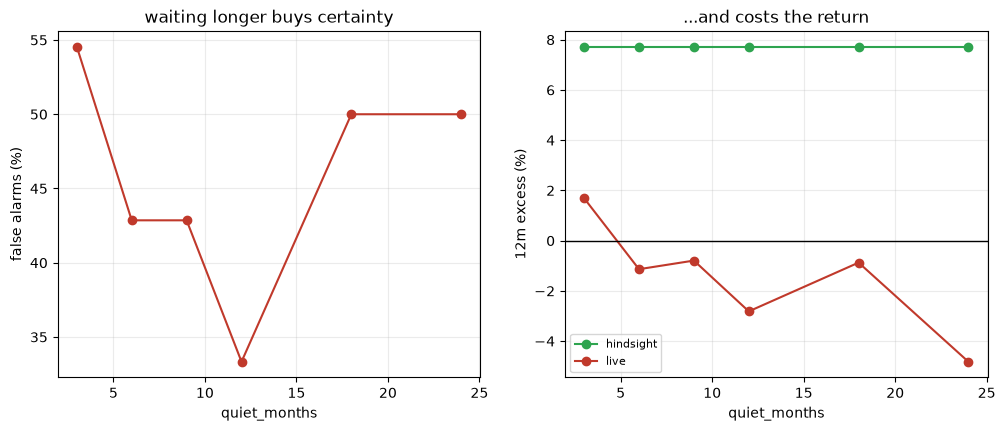

,signals,false_alarm_rate,hindsight,live
quiet_months,,,,
3,11,0.5455,0.0772,0.0169
6,7,0.4286,0.0772,-0.0114
9,7,0.4286,0.0772,-0.0079
12,6,0.3333,0.0772,-0.0281
18,6,0.5000,0.0772,-0.0087
24,6,0.5000,0.0772,-0.0482


In [5]:
rows = []
for q in (3, 6, 9, 12, 18, 24):
    fa = st.false_alarms(path, q)
    cm = st.hindsight_vs_realtime(eq, cycles, path, q, horizons_m=(12,))
    rows.append({"quiet_months": q, "signals": len(fa),
                 "false_alarm_rate": 1 - fa["was_the_end"].mean(),
                 "hindsight": cm.loc[12, "hindsight_excess"],
                 "live": cm.loc[12, "live_excess"]})
d = pd.DataFrame(rows).set_index("quiet_months")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
d["false_alarm_rate"].mul(100).plot(ax=axes[0], marker="o", color="#c0392b")
axes[0].set_ylabel("false alarms (%)"); axes[0].set_title("waiting longer buys certainty")
d[["hindsight", "live"]].mul(100).plot(ax=axes[1], marker="o",
                                       color=["#2ea44f", "#c0392b"])
axes[1].axhline(0, color="k", lw=1)
axes[1].set_ylabel("12m excess (%)"); axes[1].set_title("...and costs the return")
axes[1].legend(fontsize=8)
plt.show()
d.round(4)

> \U0001F4A1 **In plain words.** The left panel and the right panel are the same trade-off seen
> twice. Wait longer and you are more often right about the cycle being over; wait longer and
> there is less left to collect.

### 3.3 Does the cycle definition drive the answer?

 min_hikes  gap_months  cycles  excess_12m      t
         1           6       7      0.0958 1.5892
         1          12       6      0.1136 1.7456
         1          24       6      0.1136 1.7456
         2           6       5      0.0772 1.0824
         2          12       5      0.0772 1.0824
         2          24       5      0.0772 1.0824
         3           6       5      0.0772 1.0824
         3          12       5      0.0772 1.0824
         3          24       5      0.0772 1.0824
         5           6       5      0.0772 1.0824
         5          12       5      0.0772 1.0824
         5          24       5      0.0772 1.0824


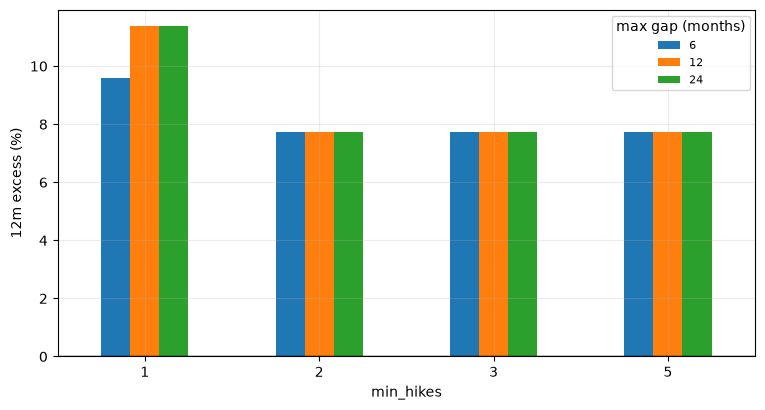

In [6]:
rows = []
for min_h in (1, 2, 3, 5):
    for gap in (6, 12, 24):
        c2 = st.tightening_cycles(path, min_hikes=min_h, gap_months=gap)
        if len(c2) < 2:
            continue
        t2 = st.event_table(eq, list(c2["last_hike"]), horizons_m=(12,))
        rows.append({"min_hikes": min_h, "gap_months": gap, "cycles": len(c2),
                     "excess_12m": t2.loc[12, "excess"], "t": t2.loc[12, "t"]})
d = pd.DataFrame(rows)
print(d.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4.5))
piv = d.pivot(index="min_hikes", columns="gap_months", values="excess_12m").mul(100)
piv.plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("12m excess (%)"); ax.legend(title="max gap (months)", fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

### 3.4 Cycle by cycle, because the average hides everything

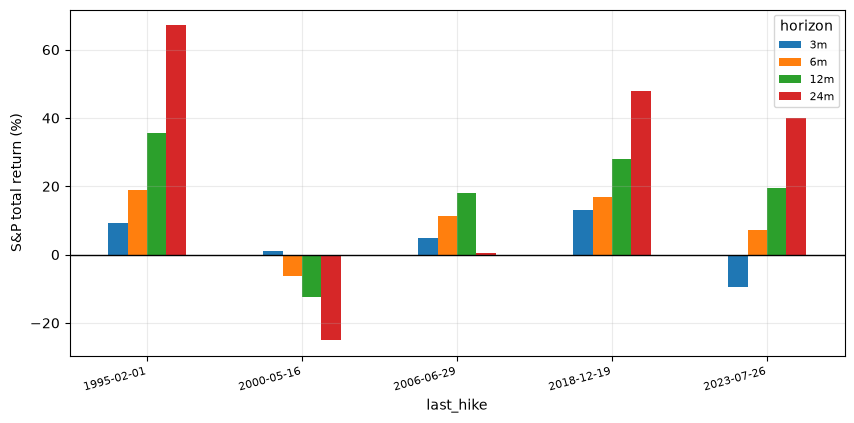

,n_hikes,3m,6m,12m,24m
last_hike,,,,,
1995-02-01,7,0.0932,0.1897,0.3573,0.6713
2000-05-16,6,0.0094,-0.0639,-0.1235,-0.2509
2006-06-29,17,0.0495,0.1143,0.1811,0.0043
2018-12-19,9,0.1299,0.1673,0.2786,0.4796
2023-07-26,11,-0.0941,0.0710,0.1954,0.3989


In [7]:
rows = []
for _, c in cycles.iterrows():
    d0 = c["last_hike"]
    r = {"last_hike": str(d0.date()), "n_hikes": int(c["n_hikes"])}
    for m in st.HORIZONS_M:
        fr = st.forward_returns(eq, [d0], horizons_m=(m,))
        r[f"{m}m"] = fr.iloc[0][f"m{m}"]
    rows.append(r)
d = pd.DataFrame(rows).set_index("last_hike")
fig, ax = plt.subplots(figsize=(10, 4.5))
d[[f"{m}m" for m in st.HORIZONS_M]].mul(100).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("S&P total return (%)"); ax.legend(fontsize=8, title="horizon")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
plt.show()
d.round(4)

### 3.5 The planted-effect control

The one place a five-observation study can still learn something: build a world where the effect
is real and large, and see how much of it a real-time rule recovers.

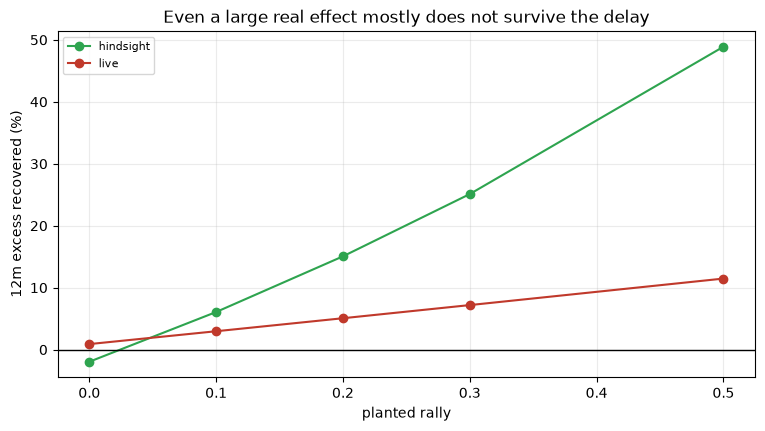

,hindsight,live
planted rally,,
0.0000,-0.0196,0.0090
0.1000,0.0607,0.0297
0.2000,0.1506,0.0507
0.3000,0.2511,0.0719
0.5000,0.4889,0.1147


In [8]:
rows = []
for alpha in (0.0, 0.1, 0.2, 0.3, 0.5):
    hind, live = [], []
    for s in range(5):
        w = st.synthetic_world(n_cycles=20, post_cycle_alpha=alpha, n_years=70, seed=985 + s)
        p2 = st.policy_path(w["moves"])
        c2 = st.tightening_cycles(p2)
        cm = st.hindsight_vs_realtime(w["prices"], c2, p2, 6, horizons_m=(12,))
        hind.append(cm.loc[12, "hindsight_excess"]); live.append(cm.loc[12, "live_excess"])
    rows.append({"planted rally": alpha, "hindsight": np.nanmean(hind),
                 "live": np.nanmean(live)})
d = pd.DataFrame(rows).set_index("planted rally")
fig, ax = plt.subplots(figsize=(9, 4.5))
d.mul(100).plot(ax=ax, marker="o", color=["#2ea44f", "#c0392b"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("12m excess recovered (%)"); ax.legend(fontsize=8, title="")
ax.set_title("Even a large real effect mostly does not survive the delay")
plt.show()
d.round(4)

## 4 · The verdict

In [9]:
cmp = st.hindsight_vs_realtime(eq, cycles, path, 6)
fa = st.false_alarms(path, 6)
wd = st.what_the_delay_costs(eq, cycles, 6)
pd.DataFrame({
    "cycles in the sample": [len(cycles)],
    "12m hindsight excess": [cmp.loc[12, "hindsight_excess"]],
    "12m hindsight t": [cmp.loc[12, "hindsight_t"]],
    "12m live excess": [cmp.loc[12, "live_excess"]],
    "live signals": [len(fa)],
    "false alarm rate": [1 - fa["was_the_end"].mean()],
    "median return given up while waiting": [wd["missed_return"].median()],
}).T.rename(columns={0: "value"}).round(4)

,value
cycles in the sample,5.0000
12m hindsight excess,0.0772
12m hindsight t,1.0824
12m live excess,-0.0114
live signals,7.0000
false alarm rate,0.4286
median return given up while waiting,0.1143


## 5 · Going further

- **Fed funds futures** as the recognition mechanism: the market prices the odds of another hike
  continuously, and a rule reading those would call the ending months earlier than "six quiet
  months" — the single highest-value extension here.
- **Condition on the reason.** A pause driven by falling inflation and a pause driven by
  something breaking are followed by different years; pooling them is most of why the dispersion
  in section 3.4 is so wide.
- **International cycles** take the sample from five to perhaps thirty, at the cost of pooling
  economies with different transmission mechanisms.
- **Bootstrap the base rate** in blocks rather than treating overlapping annual windows as
  independent — the *t*-statistics here are, if anything, generous.